# Машинное обучение, DS-поток
## Задание ML.5

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, или отдельные файлы-картинки/pdf рядом с ноутбуком, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае вставки фото в ноутбук. <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 60 баллов;
* Задача 2 &mdash; 80 баллов;
* Задача 3 &mdash; 120 баллов;
* Задача 4 &mdash; 50 баллов;
* Задача 5 &mdash; 20 баллов + бонусы до 30 баллов.

In [ ]:
# Bot check

# HW_ID: ds_ml5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.datasets import load_breast_cancer

from xgboost import XGBRegressor, XGBClassifier, plot_tree
from lightgbm import LGBMRegressor, LGBMClassifier, plot_tree as lgb_plot_tree
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

sns.set(font_scale=1.5, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
RANDOM_STATE = 42
N_JOBS = 7
from sklearn.metrics import mean_absolute_error
from tqdm.notebook import tqdm
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold
import time
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import base64
from IPython.display import Markdown, display
from sklearn.preprocessing import StandardScaler

In [143]:
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

---
### Задача 1

В модели XGBoost запишите задачу оптимизации при построении нового дерева, меру неоднородности и оптимальные ответы в листьях в следующих случаях.
1. Задача регрессии, квадратичная функция потерь $L(y, z) = (y - z)^2$.
2. Задача классификации, экспоненциальная функция потерь $L(y, z) = e^{-yz}$.
3. Задача классификации, логистическая функция потерь $L(y, z) = \ln(1 + e^{-yz})$.

В задачах классификации классификатор предсказывает степень уверенности принадлежности классу из $\mathscr{Y} \in \{-1, +1\}$. Решающее правило имеет вид $f(x) = \mathrm{sign} \widehat{y}(x)$.

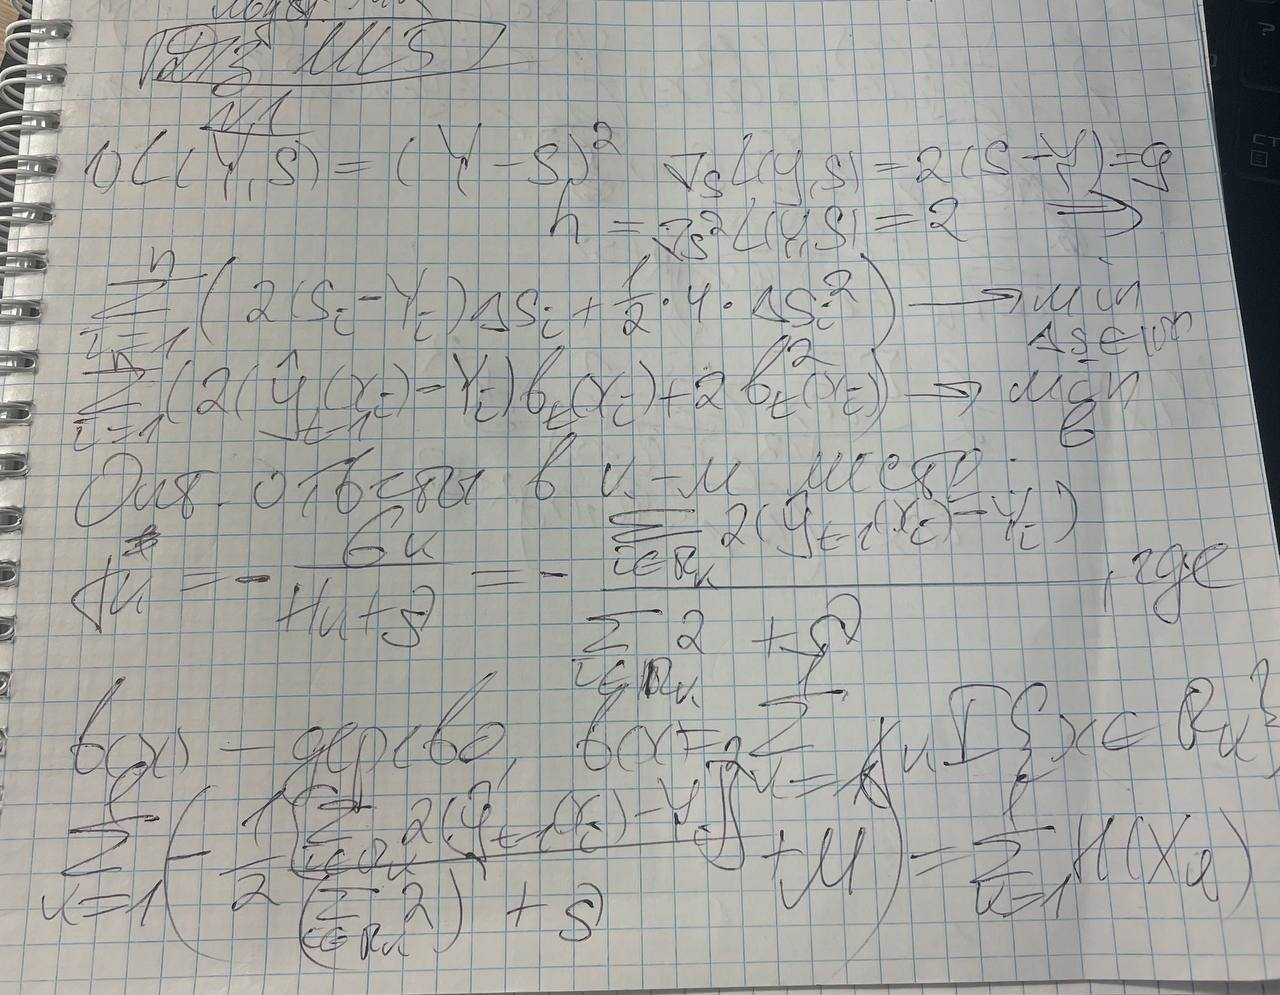

In [145]:
embed_image('1.jpg')

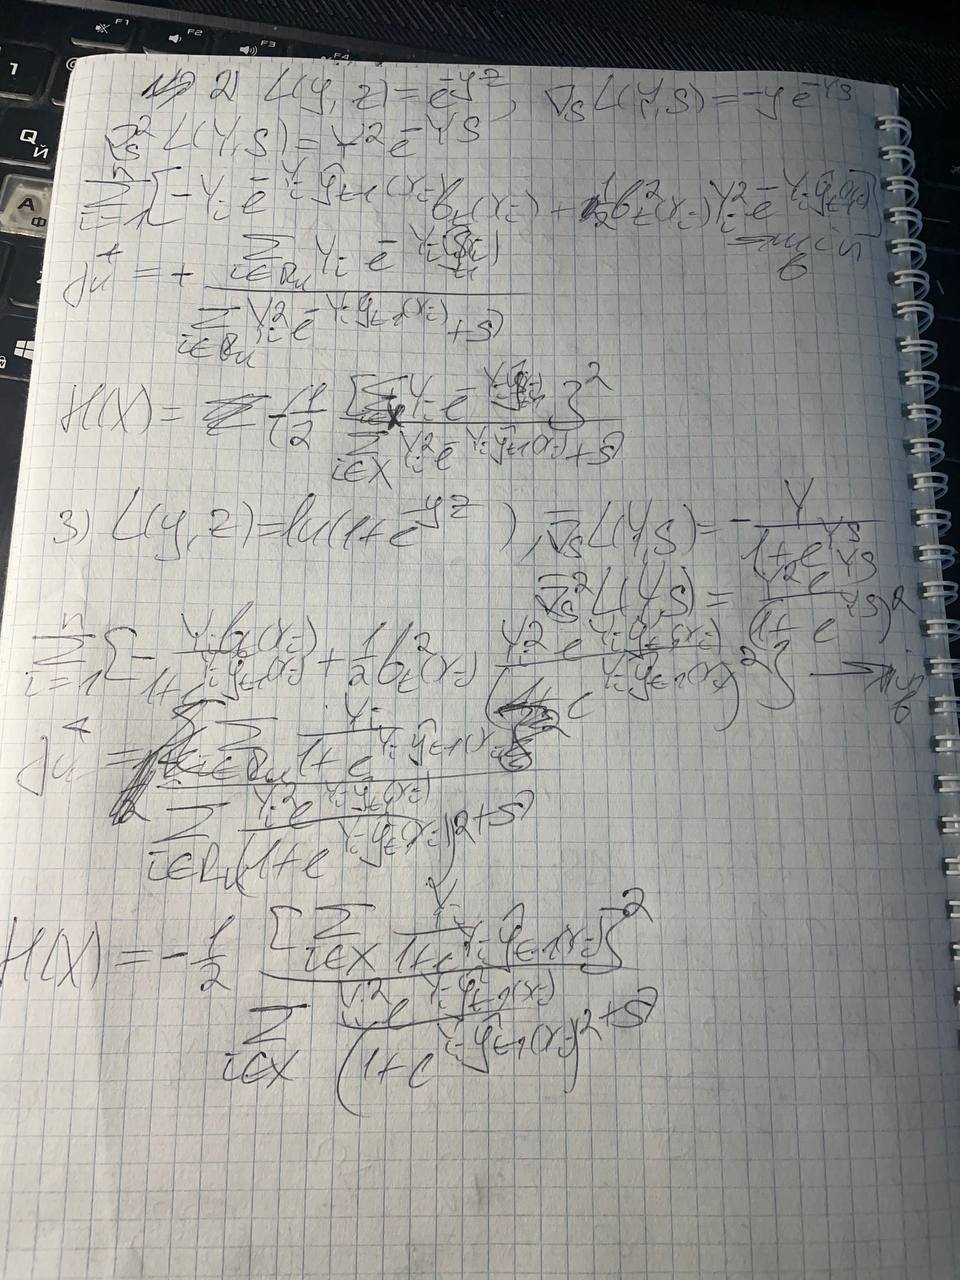

In [146]:
embed_image('2.jpg')

---
### Задача 2.

В этой задаче вам нужно будет реализовать оптимальный подсчет метрики **ROC-AUC**. Вспомним, что **ROC** &mdash; кривая в координатах **True Positive Rate (TPR)** и **False Positive Rate (FPR)**, а **ROC-AUC** &mdash; площадь под этой кривой.


**1.** Предложите алгоритм расчета метрики за $O \left(n \log n\right)$, где $n$ &mdash; размер выборки.  

*Подсказка.* Подумайте сколько всего различных пар $\left(FPR, TPR\right)$ существует.

Будем проходиться по отсортированным вероятностям и считать количество правильно порядоченных пар, а затем нормировать сумму. При этом если несколько меток разного класса имеют одинаковую вероятность, то будем считать их с весом 0.5



**2.** Реализуйте предложенный алгоритм.

In [181]:
def roc_auc(y_true, y_score):
    '''
    Вычисляет ROC-AUC за O(n log(n))
    :param y_true: истинные бинарные метки
    :param y_score: предсказанная вероятность положительного класса
    :return: значение ROC-AUC
    '''
    
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    n = len(y_true)
    n_pos = y_true.sum()
    n_neg = n - n_pos

    order = np.argsort(y_score)
    y_true_sorted = y_true[order]
    scores_sorted = y_score[order]

    neg_before = 0    
    auc_pair_sum = 0.0     

    i = 0
    while i < n:
        j = i + 1

        while j < n and scores_sorted[j] == scores_sorted[i]:
            j += 1

        group = y_true_sorted[i:j]
        pos_in_group = group.sum()
        neg_in_group = (j - i) - pos_in_group

        auc_pair_sum += pos_in_group * neg_before
        auc_pair_sum += 0.5 * pos_in_group * neg_in_group

        neg_before += neg_in_group
        i = j

    auc = auc_pair_sum / (n_pos * n_neg)
    return auc

**3.** Для проверки реализации используйте датасет `load_breast_cancer` из `sklearn.datasets`, который содержит признаки опухолей молочной железы, целевая переменная бинарная: 1 = доброкачественная, 0 = злокачественная.

Разделите данные на обучающую и тестовую выборки, обучите две любых модели классификации, получите предсказанные вероятности и сравните результат вашей функции с `sklearn.metrics.roc_auc_score`.



In [182]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [183]:
X = df.drop(['target'], axis=1)
y = df.loc[:, 'target']
X_train, X_test, y_train, y_test = train_test_split(X, y)

model1 = LogisticRegression(random_state=RANDOM_STATE, n_jobs=N_JOBS)
model2 = XGBClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model1.fit(X_train_scaled, y_train)
model2.fit(X_train, y_train)

y_proba1 = model1.predict_proba(X_test_scaled)[:, 1]
y_proba2 = model2.predict_proba(X_test)[:, 1]

In [184]:
assert np.isclose(roc_auc(y_test, y_proba1), metrics.roc_auc_score(y_test, y_proba1), atol=1e-4)

**4.** Постройте ROC-кривую по предсказанным вероятностям.

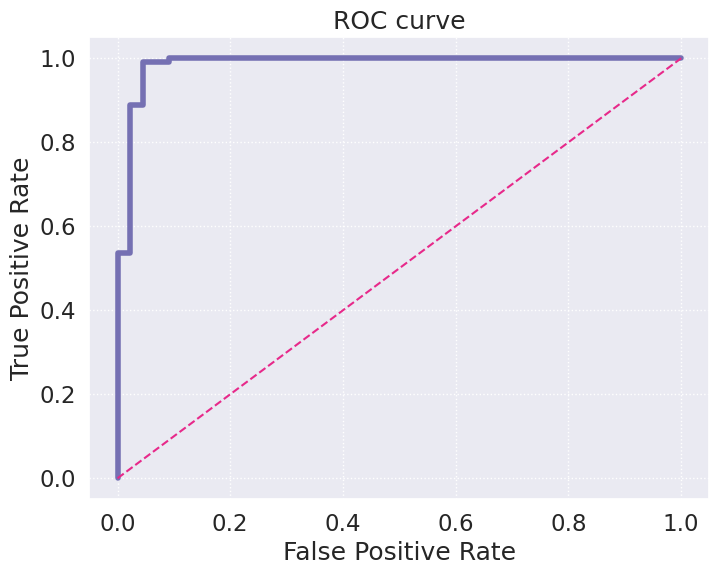

Auc: 0.986455463728191


In [192]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_proba1)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=4, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.grid(ls=":")
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print(f'Auc: {metrics.roc_auc_score(y_test, y_proba1)}')

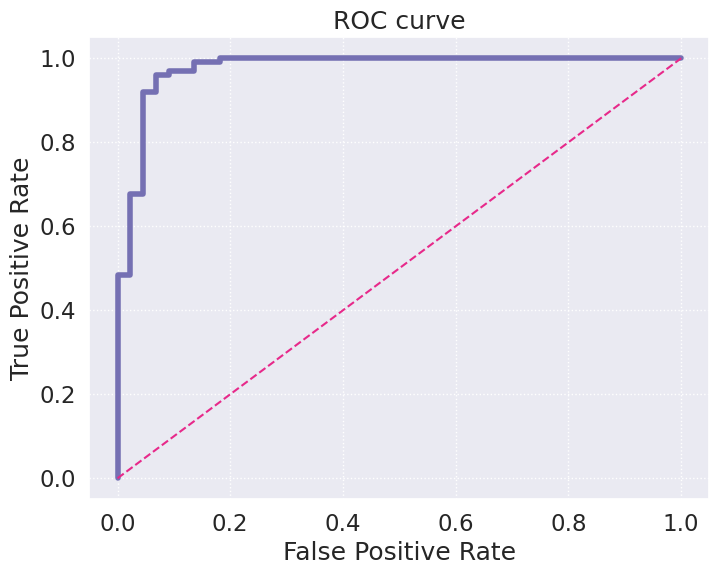

Auc: 0.9763544536271809


In [191]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_proba2)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=4, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.grid(ls=":")
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print(f'Auc: {metrics.roc_auc_score(y_test, y_proba2)}')

**Выводы:** Roc-auc - беспороговая метрика, которая позволяет понять, насколько модель хорошо классифицирует 

---
### Задача 3

В файле `houses_train.csv` представлен набор данных про квартиры в городе Сиэтл, штат Вашингтон. Задача — предсказать цену на жилье по имеющимся данным.

Данные имеют следующие столбцы:
* `id` — идентификационный номер жилья
* `date` — дата продажи дома
* `price` — цена
* `bedrooms` — количество спален
* `bathrooms` — количество ванных комнат, где .5 означает комнату с туалетом, но без душа
* `sqft_living` — площадь жилья
* `sqft_lot` — площадь участка
* `floors` — количество этажей
* `waterfront` — видна ли набережная
* `view` — насколько хороший вид
* `condition` — индекс от 1 от 5, отвечающий за состояние квартиры
* `grade` — 1 до 13, 1-3 соответствует плохому уровню строительства и дизайна, 3-7 — средний уровень, 11-13 — высокий.
* `sqft_above` — жилая площадь над уровнем земли
* `sqft_basement` — жилая площадь под уровнем земли
* `yr_built` — год постройки жилья
* `yr_renovated` — год последней реконструкции жилья
* `zipcode` — почтовый индекс
* `lat` — широта
* `long` — долгота
* `sqft_living15` — средняя площадь жилья ближайших 15-и соседей
* `sqft_lot15` — средняя площадь участка ближайших 15-и соседей

В следующей задаче вы будете работать с ними в рамках Kaggle-соревнования. Предлагаем сначала подготовиться к нему, исследовав работу различных бустинг-библиотек применительно к этим данных. Результаты этой задаче вы сможете использовать в качестве начального решения соревнования.

**1.** Исследуйте зависимость качества по метрике MAPE для моделей
* XGBoost,
* LightGBM,
* CatBoost,
* а так же градиентного бустинга из sklearn,

в зависимости от
* количества деревьев,
* их максимальной глубины,
* шага обучения,
* $\ell_1$ и $\ell_2$ регуляризаций.

При исследовании одного гиперпараметра рисуйте один график для всех моделей. Тщательно подберите цвета и тип линий, масштаб осей так, чтобы картинка была легко читаемой. При проведении исследований не забывайте писать подробные комментариии и выводы.

*Советы.*
* Используйте код с семинаров.
* Пока мы не умеем работать с признаком `zipcode`, удалите его из данных.

*Замечания.*
* Не забывайте, что для некоторых параметров стоит генерировать сетку значений при помощи `np.logspace`.

In [3]:
data = pd.read_csv('train.csv')
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3392,20151013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,18295,20151209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,14569,20151209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
3,14081,20160218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
4,6725,20150627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15621,20922,20160126T000000,429000.0,3,2.00,1490,1126,3.0,0,0,...,8,1490,0,2014,0,98144,47.5699,-122.288,1400,1230
15622,13963,20151014T000000,610685.0,4,2.50,2520,6023,2.0,0,0,...,9,2520,0,2014,0,98056,47.5137,-122.167,2520,6023
15623,9850,20150521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
15624,13975,20160223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200


In [4]:
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [5]:
data.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [6]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

In [7]:
X = data.drop(['date', 'price', 'zipcode'], axis=1)
y = data.loc[:, 'price']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

In [8]:
depth_grid = np.arange(3, 16)
weight_grid = np.arange(1, 51)
alpha_grid = np.linspace(0, 1, 20)
lambda_grid = np.linspace(0, 1, 20)
rate_grid = np.linspace(0.05, 0.3, 15)

In [15]:
x_res_depth = []
l_res_depth = []
c_res_depth = []

for depth in tqdm(depth_grid):

    xmodel = XGBRegressor(max_depth=depth,
                          random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    xmodel.fit(X_train, y_train)
    y_pred_x = xmodel.predict(X_test)
    x_res_depth.append(mean_absolute_error(y_test, y_pred_x))

    lmodel = LGBMRegressor(max_depth=depth,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lmodel.fit(X_train, y_train)
    y_pred_l = lmodel.predict(X_test)
    l_res_depth.append(mean_absolute_error(y_test, y_pred_l))

    cmodel = CatBoostRegressor(max_depth=depth,
                               random_state=RANDOM_STATE, verbose=0, thread_count=-1)
    cmodel.fit(X_train, y_train)
    y_pred_c = cmodel.predict(X_test)
    c_res_depth.append(mean_absolute_error(y_test, y_pred_c))



  0%|          | 0/13 [00:00<?, ?it/s]

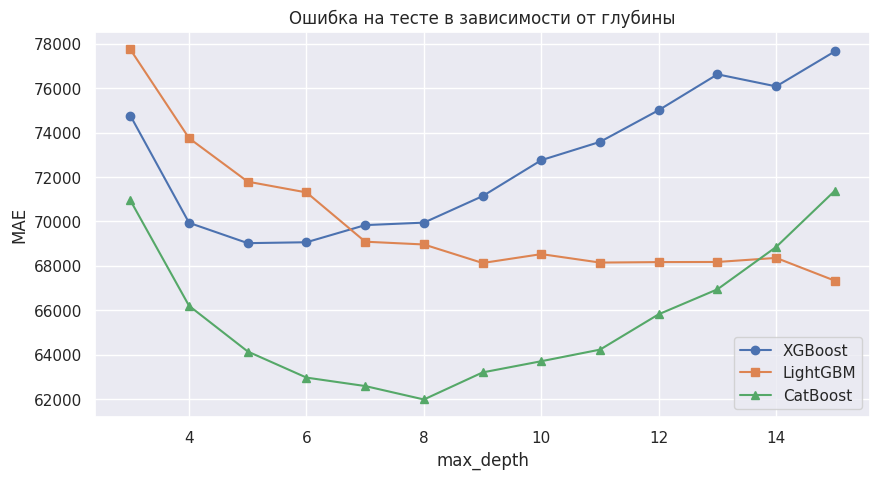

In [16]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,5))
plt.plot(depth_grid, x_res_depth, marker='o', label='XGBoost')
plt.plot(depth_grid, l_res_depth, marker='s', label='LightGBM')
plt.plot(depth_grid, c_res_depth, marker='^', label='CatBoost')
plt.xlabel('max_depth')
plt.ylabel('MAE')
plt.title('Ошибка на тесте в зависимости от глубины')
plt.legend()
plt.show()

In [73]:
opt_depth_x = 6
opt_depth_l = 9
opt_depth_c = 8

In [23]:
x_res_weight = []
l_res_weight = []
c_res_weight = []

for weight in tqdm(weight_grid):

    xmodel = XGBRegressor(min_child_weight=weight,
                          max_depth=opt_depth_x,
                          random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    xmodel.fit(X_train, y_train)
    y_pred_x = xmodel.predict(X_test)
    x_res_weight.append(mean_absolute_error(y_test, y_pred_x))

    lmodel = LGBMRegressor(min_child_weight=weight,
                           max_depth=opt_depth_l,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lmodel.fit(X_train, y_train)
    y_pred_l = lmodel.predict(X_test)
    l_res_weight.append(mean_absolute_error(y_test, y_pred_l))

    cmodel = CatBoostRegressor(min_data_in_leaf=weight,
                               max_depth=opt_depth_c,
                               random_state=RANDOM_STATE, verbose=0, thread_count=-1)
    cmodel.fit(X_train, y_train)
    y_pred_c = cmodel.predict(X_test)
    c_res_weight.append(mean_absolute_error(y_test, y_pred_c))

  0%|          | 0/50 [00:00<?, ?it/s]

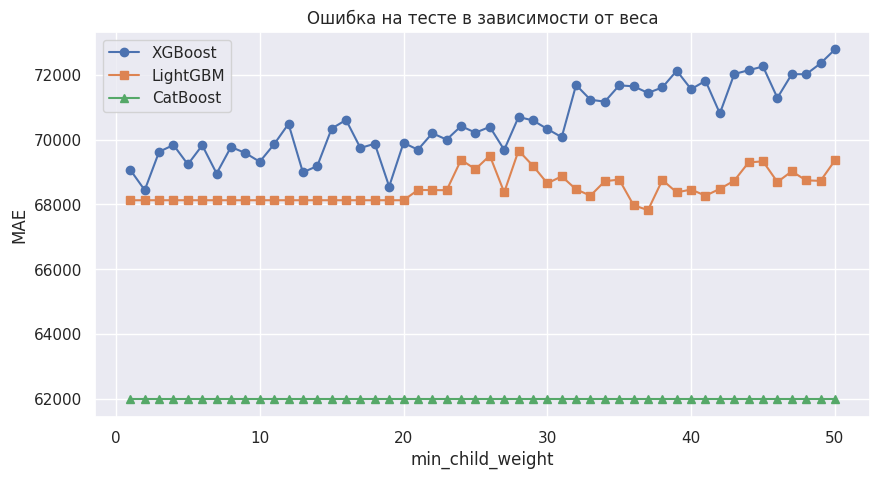

In [24]:
plt.figure(figsize=(10,5))
plt.plot(weight_grid, x_res_weight, marker='o', label='XGBoost')
plt.plot(weight_grid, l_res_weight, marker='s', label='LightGBM')
plt.plot(weight_grid, c_res_weight, marker='^', label='CatBoost')
plt.xlabel('min_child_weight')
plt.ylabel('MAE')
plt.title('Ошибка на тесте в зависимости от веса')
plt.legend()
plt.show()

In [74]:
opt_weight_x = weight_grid[np.argmin(x_res_weight)] # 2
opt_weight_l = weight_grid[np.argmin(l_res_weight)] # 36
opt_weight_c = None

NameError: name 'x_res_weight' is not defined

In [28]:
x_res_rate = []
l_res_rate = []
c_res_rate = []

for rate in tqdm(rate_grid):

    xmodel = XGBRegressor(learning_rate=rate,
                          min_child_weight=opt_weight_x,
                          max_depth=opt_depth_x,
                          random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    xmodel.fit(X_train, y_train)
    y_pred_x = xmodel.predict(X_test)
    x_res_rate.append(mean_absolute_error(y_test, y_pred_x))

    lmodel = LGBMRegressor(learning_rate=rate,
                           min_child_weight=opt_weight_l,
                           max_depth=opt_depth_l,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lmodel.fit(X_train, y_train)
    y_pred_l = lmodel.predict(X_test)
    l_res_rate.append(mean_absolute_error(y_test, y_pred_l))

    cmodel = CatBoostRegressor(learning_rate=rate,
                               max_depth=opt_depth_c,
                               random_state=RANDOM_STATE, verbose=0, thread_count=-1)
    cmodel.fit(X_train, y_train)
    y_pred_c = cmodel.predict(X_test)
    c_res_rate.append(mean_absolute_error(y_test, y_pred_c))

  0%|          | 0/15 [00:00<?, ?it/s]

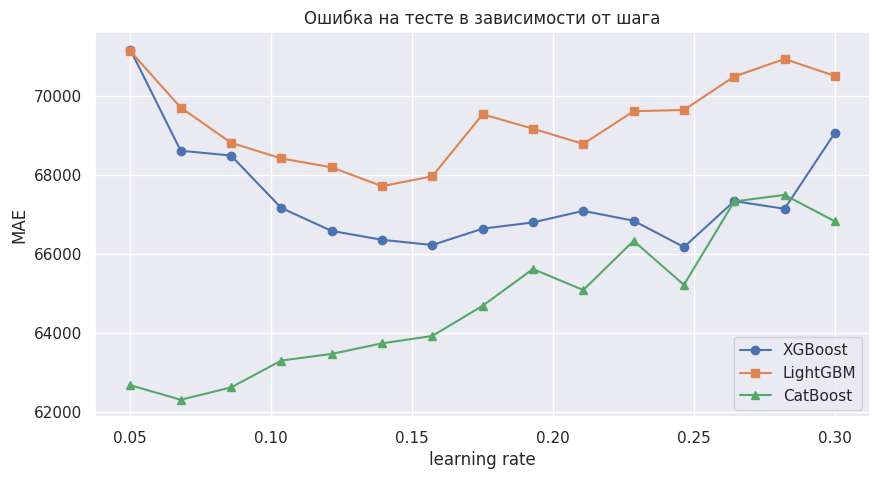

In [30]:
plt.figure(figsize=(10,5))
plt.plot(rate_grid, x_res_rate, marker='o', label='XGBoost')
plt.plot(rate_grid, l_res_rate, marker='s', label='LightGBM')
plt.plot(rate_grid, c_res_rate, marker='^', label='CatBoost')
plt.xlabel('learning rate')
plt.ylabel('MAE')
plt.title('Ошибка на тесте в зависимости от шага')
plt.legend()
plt.show()

In [69]:
opt_lr_x = rate_grid[np.argmin(x_res_rate)] # 0.26428571
opt_lr_l = rate_grid[np.argmin(l_res_rate)] # 0.13928571
opt_lr_c = rate_grid[np.argmin(c_res_rate)] # 0.06785714

In [42]:
x_res_alpha = []
l_res_alpha = []
c_res_alpha = []

for alpha in tqdm(alpha_grid):
    xmodel = XGBRegressor(learning_rate=opt_lr_x,
                          min_child_weight=opt_weight_x,
                          reg_alpha=alpha,
                          max_depth=opt_depth_x,
                          random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    xmodel.fit(X_train, y_train)
    y_pred_x = xmodel.predict(X_test)
    x_res_alpha.append(mean_absolute_error(y_test, y_pred_x))

    lmodel = LGBMRegressor(learning_rate=opt_lr_l,
                           min_child_weight=opt_weight_l,
                           reg_alpha=alpha,
                           max_depth=opt_depth_l,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lmodel.fit(X_train, y_train)
    y_pred_l = lmodel.predict(X_test)
    l_res_alpha.append(mean_absolute_error(y_test, y_pred_l))

    cmodel = CatBoostRegressor(learning_rate=opt_lr_c,
                               l2_leaf_reg=alpha,
                               max_depth=opt_depth_c,
                               random_state=RANDOM_STATE, verbose=0, thread_count=-1)
    cmodel.fit(X_train, y_train)
    y_pred_c = cmodel.predict(X_test)
    c_res_alpha.append(mean_absolute_error(y_test, y_pred_c))


  0%|          | 0/20 [00:00<?, ?it/s]

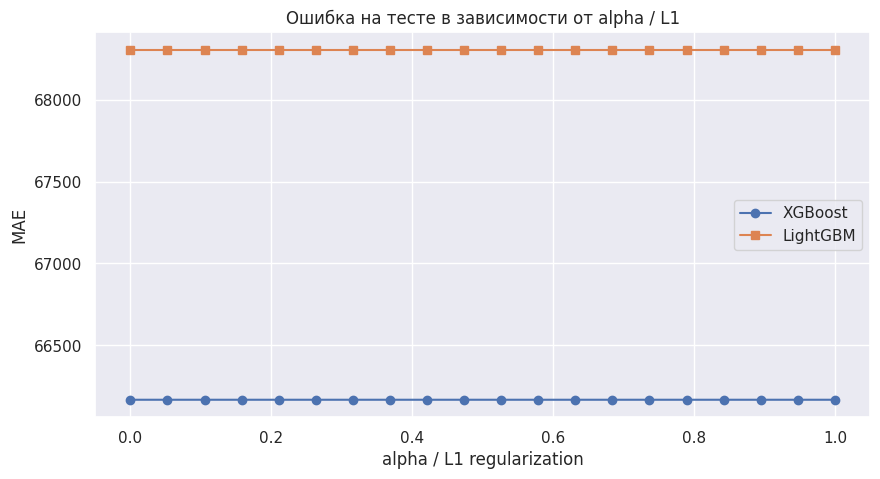

In [46]:
plt.figure(figsize=(10,5))
plt.plot(alpha_grid, x_res_alpha, marker='o', label='XGBoost')
plt.plot(alpha_grid, l_res_alpha, marker='s', label='LightGBM')
plt.xlabel('alpha / L1 regularization')
plt.ylabel('MAE')
plt.title('Ошибка на тесте в зависимости от alpha / L1')
plt.legend()
plt.show()

In [47]:
x_res_lambda = []
l_res_lambda = []

for lamb in tqdm(lambda_grid):
    xmodel = XGBRegressor(reg_lambda=lamb,
                          learning_rate=opt_lr_x,
                          min_child_weight=opt_weight_x,
                          max_depth=opt_depth_x,
                          random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    xmodel.fit(X_train, y_train)
    y_pred_x = xmodel.predict(X_test)
    x_res_lambda.append(mean_absolute_error(y_test, y_pred_x))

    lmodel = LGBMRegressor(reg_lambda=lamb,
                           learning_rate=opt_lr_l,
                           min_child_weight=opt_weight_l,
                           max_depth=opt_depth_l,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lmodel.fit(X_train, y_train)
    y_pred_l = lmodel.predict(X_test)
    l_res_lambda.append(mean_absolute_error(y_test, y_pred_l))

  0%|          | 0/20 [00:00<?, ?it/s]

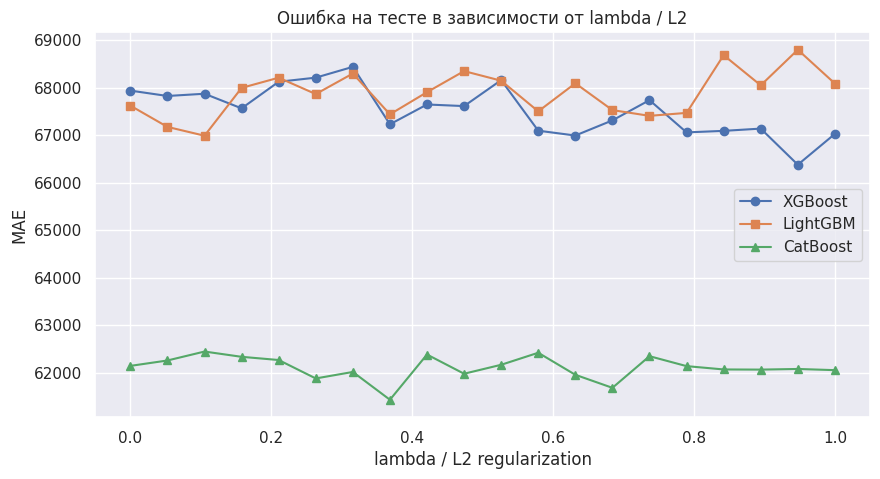

In [48]:
plt.figure(figsize=(10,5))
plt.plot(lambda_grid, x_res_lambda, marker='o', label='XGBoost')
plt.plot(lambda_grid, l_res_lambda, marker='s', label='LightGBM')
plt.plot(alpha_grid, c_res_alpha, marker='^', label='CatBoost')
plt.xlabel('lambda / L2 regularization')
plt.ylabel('MAE')
plt.title('Ошибка на тесте в зависимости от lambda / L2')
plt.legend()
plt.show()

In [67]:
opt_reg_lambda_x = 0.10526316
opt_reg_lambda_l = 0.94736842
opt_reg_lambda_c = 0.36842105

**2.** Нарисуйте по несколько деревьев каждой из моделей с помощью функций `plot_tree`, которая реализована в каждой из библиотек. Для этого потребуется немного разобраться с тем, как работают эти функции.

Какие особенности можно заметить? Как меняются деревья при изменении максимальной глубины? Что выдает CatBoost в листе, если в него не попали объекты обучающей выборки?

In [9]:
xmodel = XGBRegressor(verbosity=0)
lmodel = LGBMRegressor(verbose=-1)
cmodel = CatBoostRegressor(verbose=0)

xmodel.fit(X_train, y_train)
lmodel.fit(X_train, y_train)
cmodel.fit(X_train, y_train);

In [38]:
plt.figure(figsize=(60, 30))  
plot_tree(xmodel, tree_idx=0, rankdir='LR')
plt.savefig('xtree.png', dpi=1000)
plt.close();

<Figure size 6000x3000 with 0 Axes>

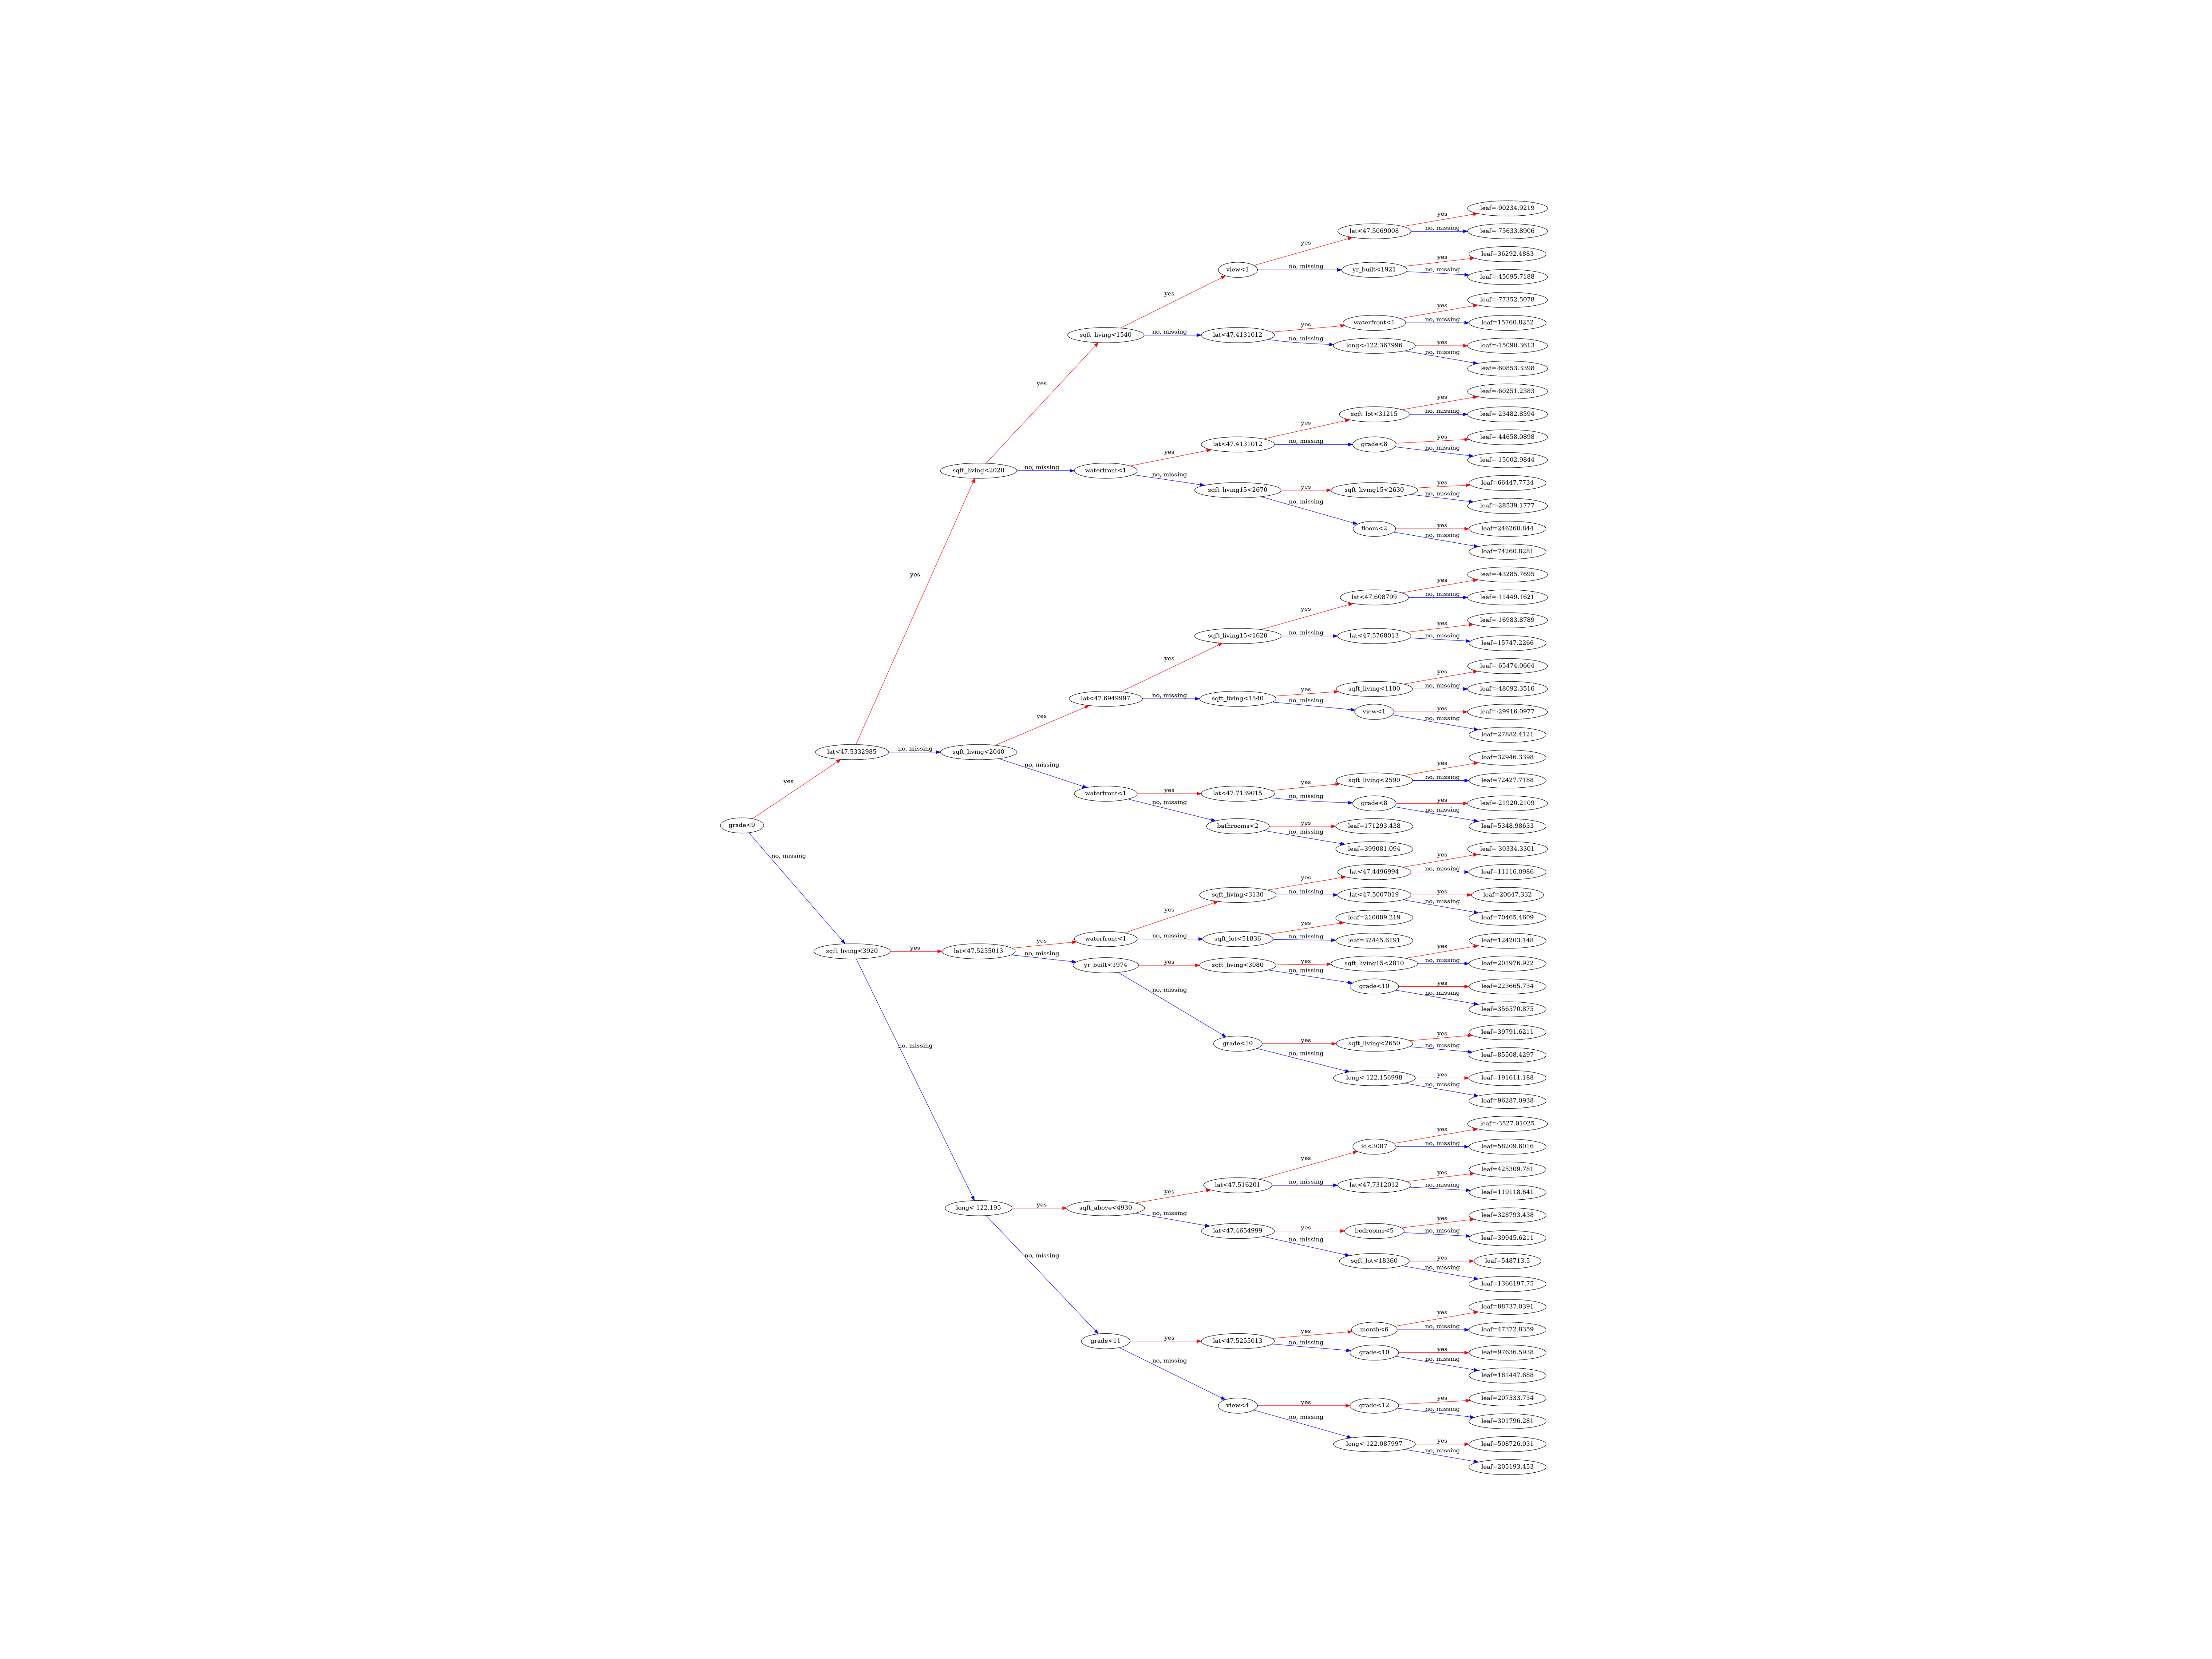

In [141]:
embed_image("xtree.png")

In [15]:
plt.figure(figsize=(60, 30))  
lgb_plot_tree(lmodel, tree_index=0)
plt.savefig('ltree.png', dpi=1000)
plt.close();

<Figure size 6000x3000 with 0 Axes>

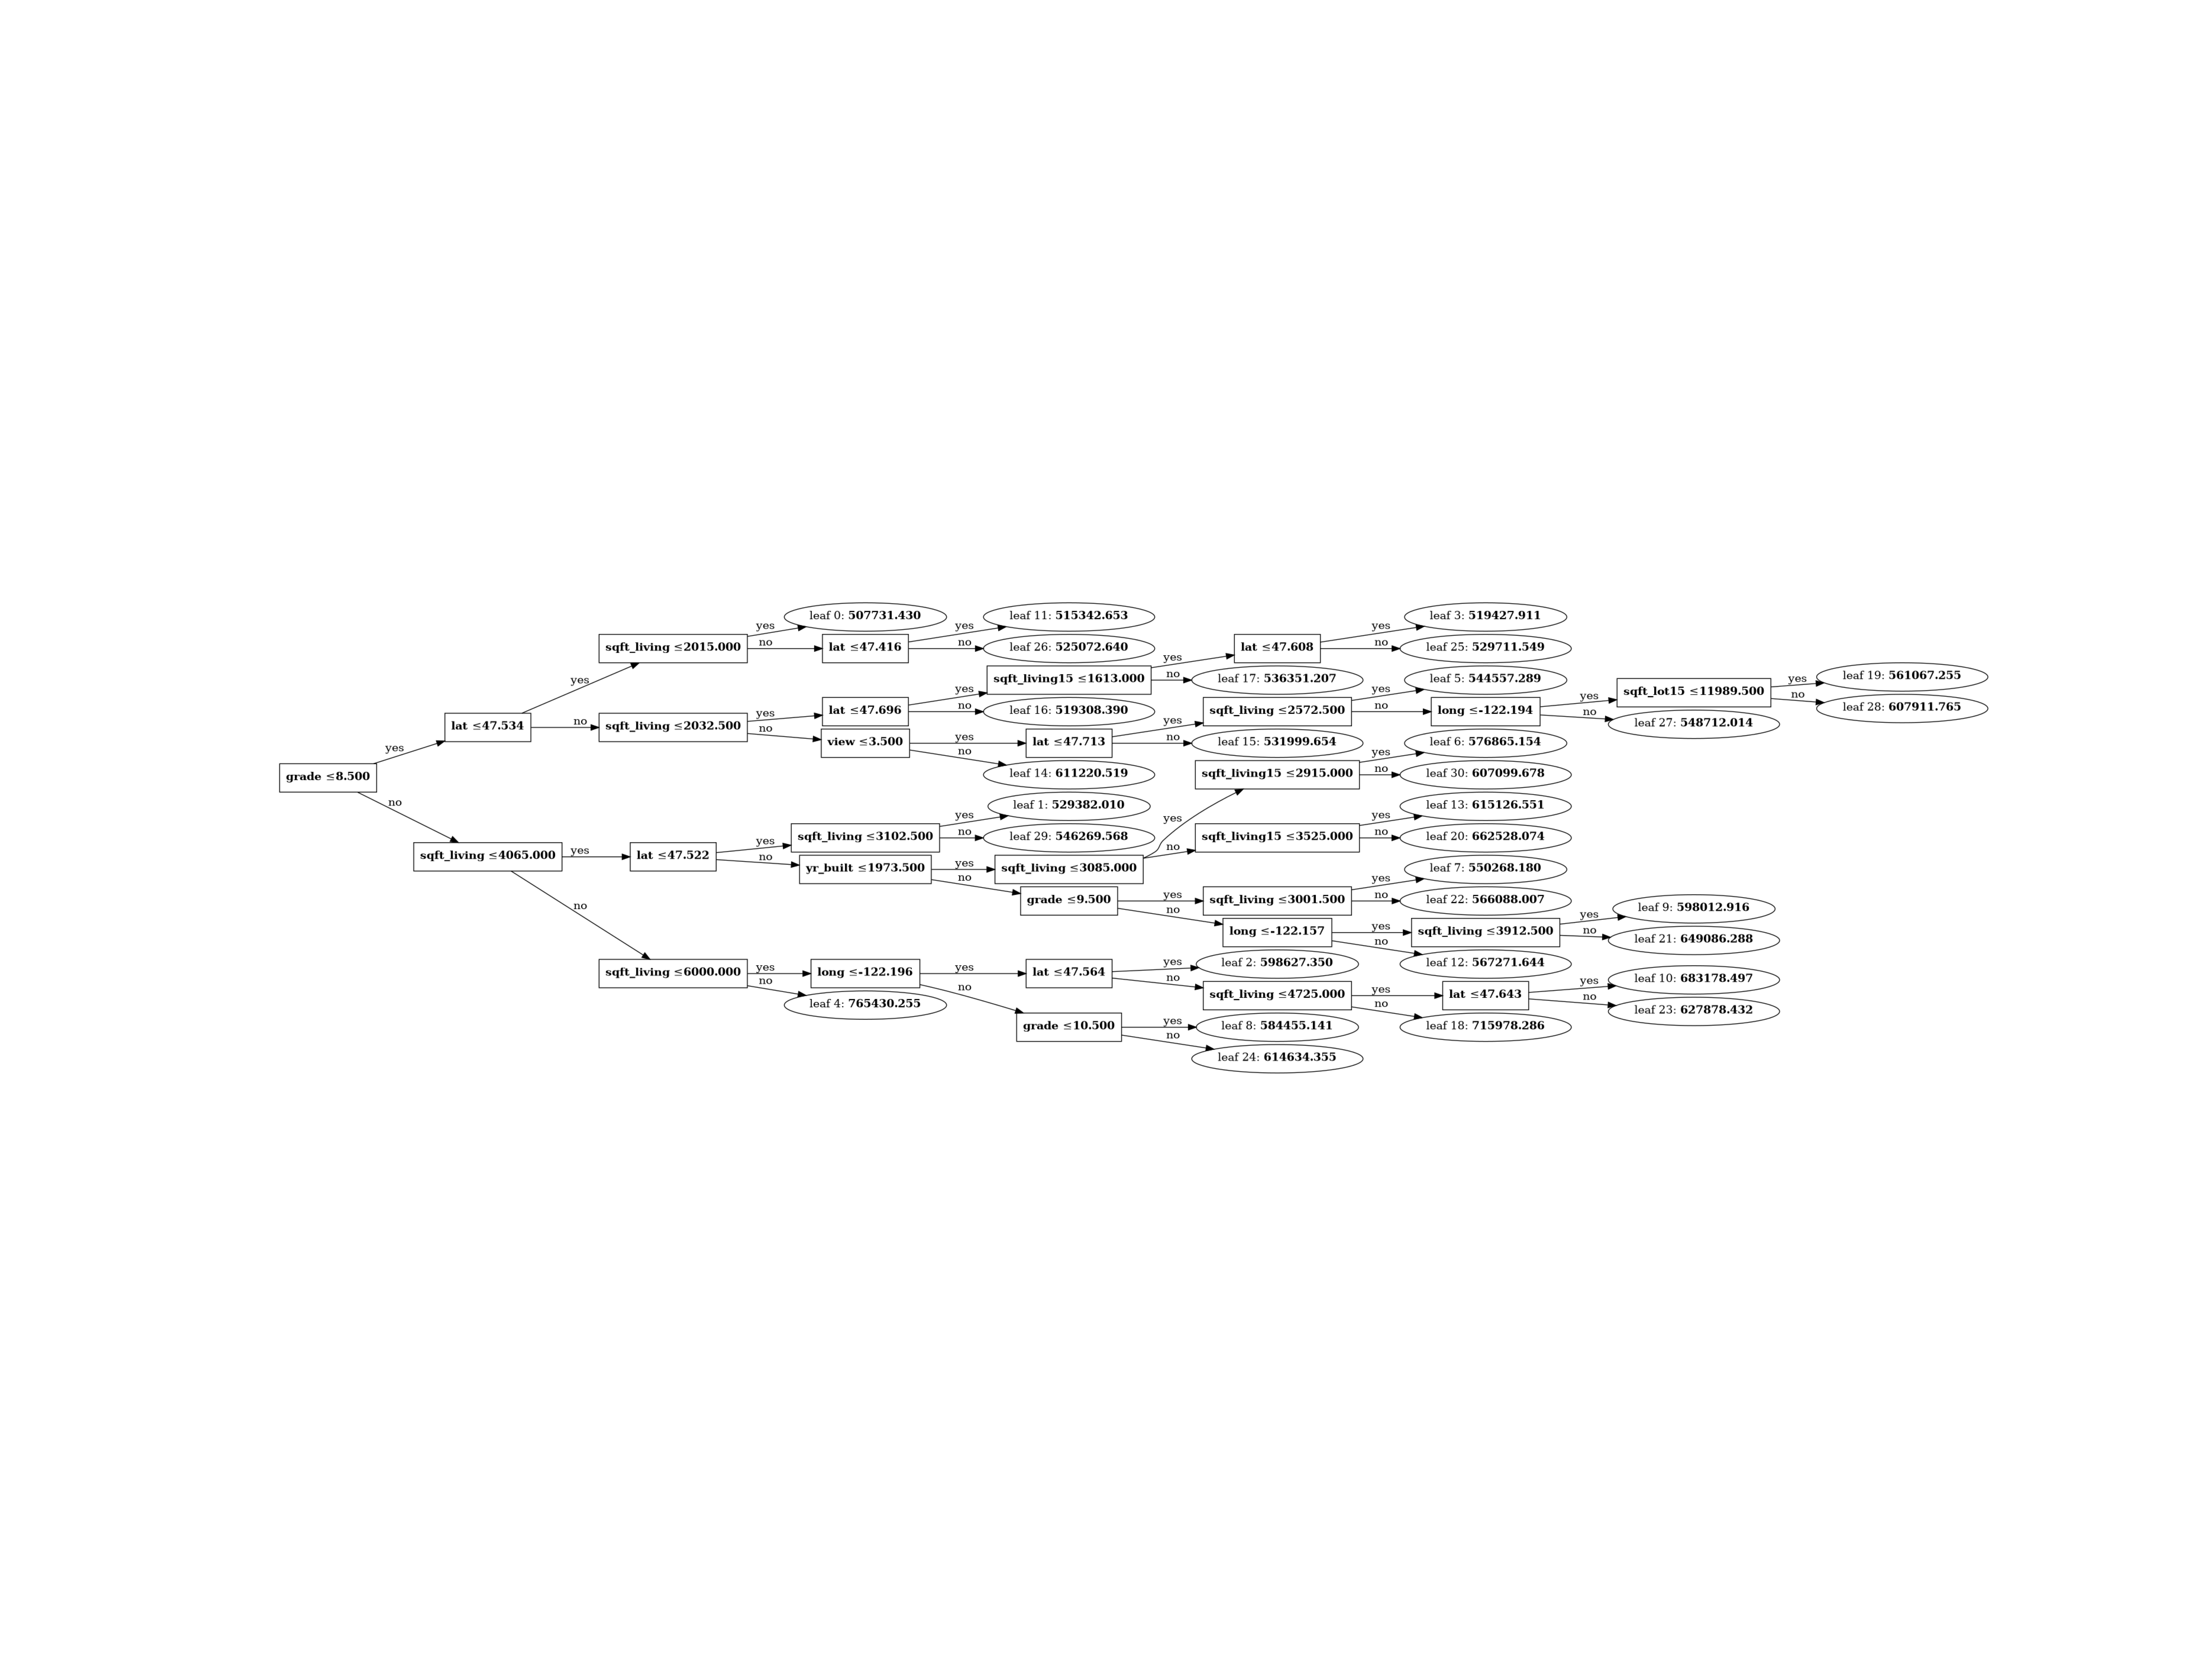

In [142]:
embed_image("ltree.png")

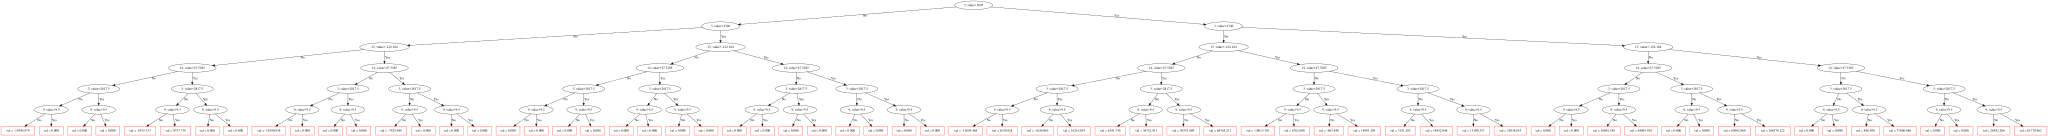

<Figure size 2000x1000 with 0 Axes>

In [134]:
plt.figure(figsize=(20, 10))
cmodel.plot_tree(tree_idx=0) 

**3.** Исследуйте среднее время обучения и предсказания для разных моделей. Для более честного сравнения для каждой модели стоит использовать те значения гиперпараметров, которые для нее оптимальны.

In [58]:
depth_grid = np.arange(3, 16)
weight_grid = np.arange(1, 51)
alpha_grid = np.linspace(0, 1, 20)
lambda_grid = np.linspace(0, 1, 20)
rate_grid = np.linspace(0.05, 0.3, 15)

In [59]:
depth_grid

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [89]:
xmodel = XGBRegressor(learning_rate=opt_lr_x,
                      max_depth=opt_depth_x,
                      min_child_weight=opt_weight_x,
                      reg_lambda=opt_reg_lambda_x,
                      verbosity=0, random_state=RANDOM_STATE, n_jobs=N_JOBS)
lmodel = LGBMRegressor(learning_rate=opt_lr_l,
                       max_depth=opt_depth_l,
                       min_child_weight=opt_weight_l,
                       reg_lamda=opt_reg_lambda_l,
                       verbose=-1, random_state=RANDOM_STATE, n_jobs=N_JOBS)
cmodel = CatBoostRegressor(learning_rate=opt_lr_c,
                           max_depth=opt_depth_x,
                           l2_leaf_reg=opt_reg_lambda_c,
                           verbose=0, random_state=RANDOM_STATE, thread_count=N_JOBS)

In [90]:
N_exp = 50
x_fit = []
x_pred = []
xmae = []
l_fit = []
l_pred = []
lmae = []
c_fit = []
c_pred = []
cmae = []

In [91]:
for i in tqdm(range(N_exp)):
    start_time = time.time()
    xmodel.fit(X_train, y_train)
    end_time = time.time()
    
    x_fit.append(end_time - start_time)

    start_time = time.time()
    y_pred = xmodel.predict(X_test)
    end_time = time.time()

    x_pred.append(end_time - start_time)

    xmae.append(mean_absolute_error(y_test, y_pred))

  0%|          | 0/50 [00:00<?, ?it/s]

In [92]:
for i in tqdm(range(N_exp)):
    start_time = time.time()
    lmodel.fit(X_train, y_train)
    end_time = time.time()
    
    l_fit.append(end_time - start_time)

    start_time = time.time()
    y_pred = lmodel.predict(X_test)
    end_time = time.time()

    l_pred.append(end_time - start_time)

    lmae.append(mean_absolute_error(y_test, y_pred))

  0%|          | 0/50 [00:00<?, ?it/s]

In [93]:
for i in tqdm(range(N_exp)):
    start_time = time.time()
    cmodel.fit(X_train, y_train)
    end_time = time.time()
    
    c_fit.append(end_time - start_time)

    start_time = time.time()
    y_pred = cmodel.predict(X_test)
    end_time = time.time()

    c_pred.append(end_time - start_time)

    cmae.append(mean_absolute_error(y_test, y_pred))

  0%|          | 0/50 [00:00<?, ?it/s]

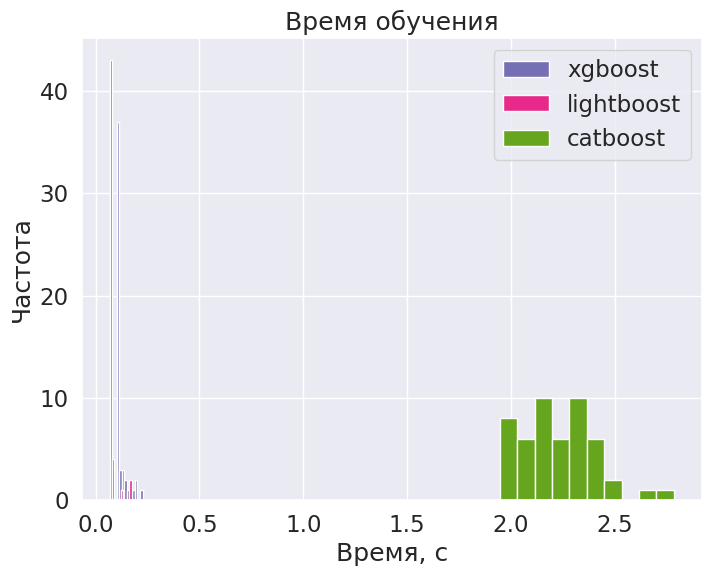

In [109]:
plt.figure(figsize=(8, 6))
plt.hist(x_fit, label='xgboost')
plt.hist(l_fit, label='lightboost')
plt.hist(c_fit, label='catboost')
plt.title('Время обучения')
plt.xlabel('Время, с')
plt.ylabel('Частота')
plt.legend()
plt.show()

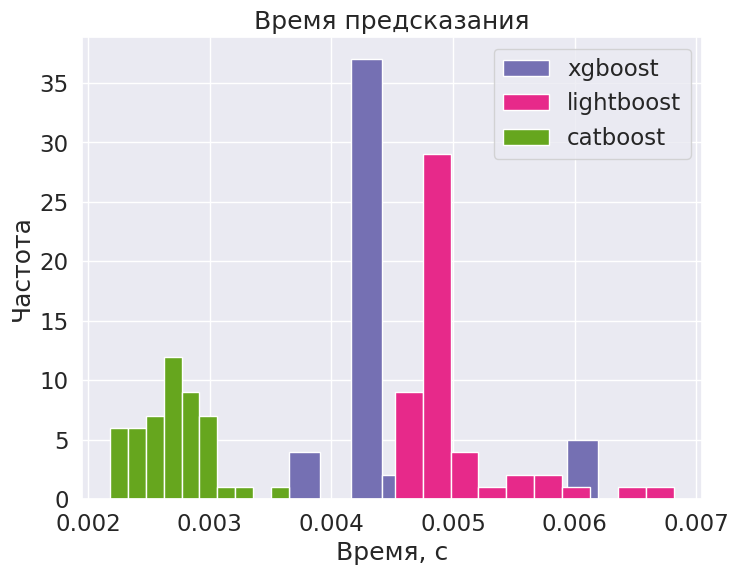

In [111]:
plt.figure(figsize=(8, 6))
plt.hist(x_pred, label='xgboost')
plt.hist(l_pred, label='lightboost')
plt.hist(c_pred, label='catboost')
plt.title('Время предсказания')
plt.xlabel('Время, с')
plt.ylabel('Частота')
plt.legend()
plt.show()

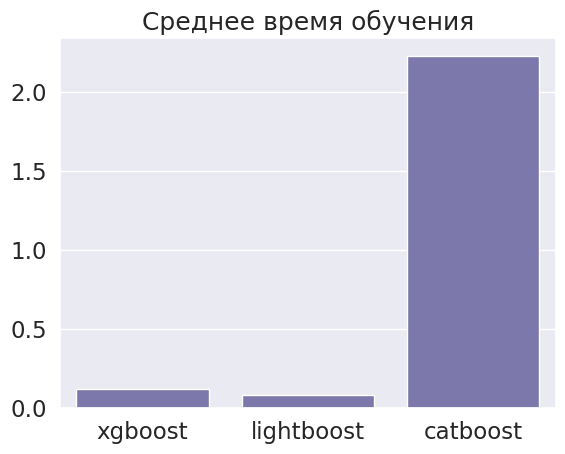

In [104]:
sns.barplot(y=[np.mean(x_fit), np.mean(l_fit), np.mean(c_fit)], x=['xgboost', 'lightboost', 'catboost'])
plt.title('Среднее время обучения')
plt.show()

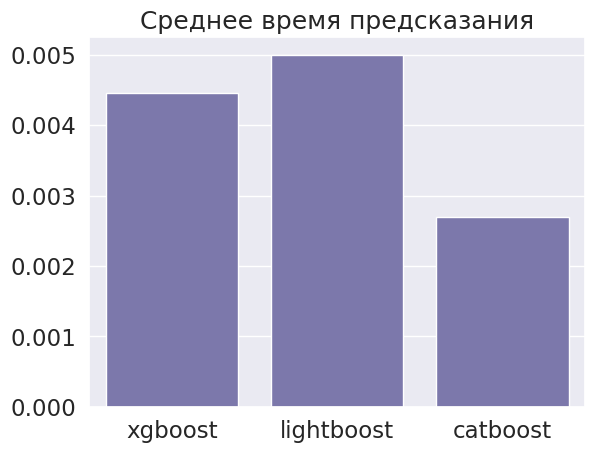

In [108]:
sns.barplot(y=[np.mean(x_pred), np.mean(l_pred), np.mean(c_pred)], x=['xgboost', 'lightboost', 'catboost'])
plt.title('Среднее время предсказания')
plt.show()

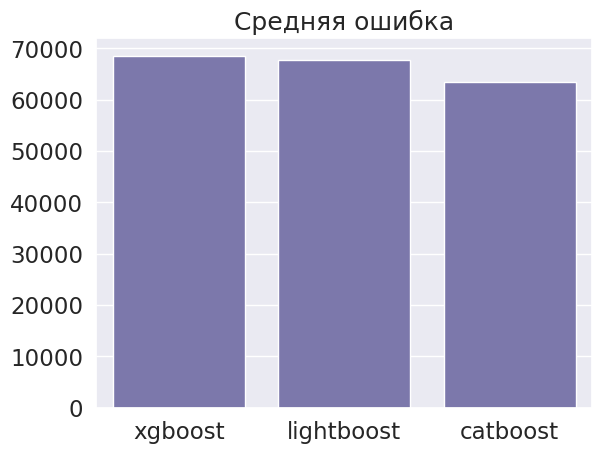

In [115]:
sns.barplot(y=[np.mean(xmae), np.mean(lmae), np.mean(cmae)], x=['xgboost', 'lightboost', 'catboost'])
plt.title('Средняя ошибка')
plt.show()

**Выводы:** Видим, что xgboost учится немного дольше lightgbm, а catboost сильно дольше из обоих. Однако и метрику он выдаёт более хорошую

---
### Задача 4

**1.** Опишите разницу между стекингом и блендингом:

Блендинг - частный случай стекинга, когда метамодель линейна

**2.** Воспользуйтесь датасетом из предыдущей задачи. Обучите стеккинг на данных о квартирах. В качестве базовых моделей используйте XGBoost, LightGBM и CatBoost, а в качестве метамодели &mdash; линейную регрессию.

In [126]:
stacking = StackingRegressor(estimators=[('xgboost', xmodel), 
                              ('lightgbm', lmodel),
                              ('catboost', cmodel)], final_estimator=Ridge())
stacking.fit(X_train, y_train)

,estimators,"[('xgboost', ...), ('lightgbm', ...), ...]"
,final_estimator,Ridge()
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [127]:
y_pred = stacking.predict(X_test)

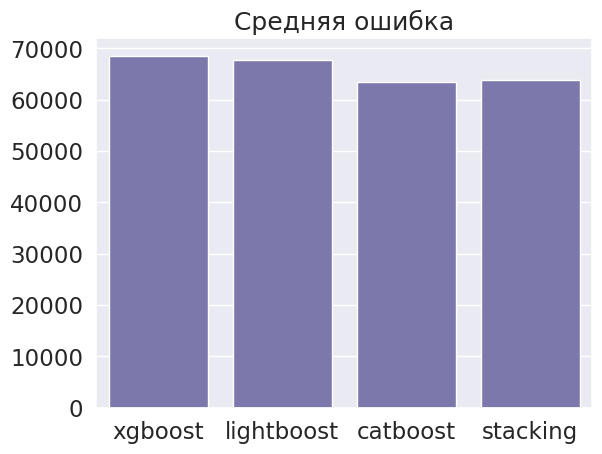

In [128]:
sns.barplot(y=[np.mean(xmae), np.mean(lmae), np.mean(cmae), mean_absolute_error(y_pred, y_test)], x=['xgboost', 'lightboost', 'catboost', 'stacking'])
plt.title('Средняя ошибка')
plt.show()

**3.** Влияет ли стекинг на качество предсказаний? Сделайте выводы.

Влияет. Если подобрать гиперпараметры, можно ещё улучшить, однако пока catboost даёт лучше метрику

**Выводы:** Стекинг как метамодель более гибкая в обучении, и потому способна получит метрику выше чем градиентный бустинг в отдельности

---
### Задача 5

В продолжении исследований из предыдущей задачи выберите некоторое количество хороших на ваш взгляд моделей, постройте для них предсказание на тестовой выборке. Полученные предсказания отправьте в тренировочное соревнование на Kaggle.

Ссылка: https://www.kaggle.com/competitions/ds-3-2025-ml-5/

Инвайт: https://www.kaggle.com/t/acdd4c00e62b44168b93770c96e57d46

**Правила**

* В Kaggle в данное тренировочное соревнование можно отправлять не более 7 решений в день (8-ю система не позволит).
* Решения индивидуальные.
* Качество считается по метрике MAPE.
* До окончания соревнования доступны значения качества, посчитанные только на случайных 30% тестовых данных. Значения отображаются в Public Leaderboard
* После окончания соревнования становится доступным Private Leaderboard, в котором значения качества посчитанны на оставшихся 70% объектов.
* Для включения в Private Leaderboard можно выбрать две посылки.
* В Leaderboard должны отображаться ваши **реальные имя и фамилия**. В противном случае решение может быть не зачтено.
* Все файлы, которые вы отправляете в соревнование, видны организаторам соревнования. Файлы должны иметь понятное имя, при отправке файла в систему необходимо написать краткое описание решения. **Это будет проверяться.**
* В решении, отправляемом боту, должно быть отображено, результаты каких моделей вы отправляете в соревнование.
* Не забывайте сделать пояснения к своему решению. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* Пользоваться можно любыми пройденными в наших курсах моделями.
* Нельзя пользоваться любыми методами и моделями, которые мы не проходили, и которых не было в ранее в иных курсах, которые обязательны для всех.
* Код студентов, занявших первые 3 места, будет запускаться. Также выборочно может запускаться код и остальных студентов.

**Сроки сдачи**

* **Дедлайн в Kaggle** совпадает с дедлайном по заданию. Дедлайн строгий, Kaggle не позволит сдать даже на секунду позже.
* Также **до дедлайна необходимо сдать в бот** существующий вариант решения, возможно, без пояснений.
* **До 23:59 следующих суток** необходимо дооформить решение, соответствующее наилучшему варианту по Private Leaderboard и сдать в бот по отдельной кнопке. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* В случае, если вы до основного дедлайна сдаете оформленное решение, его нужно сдать по двум кнопкам сразу &mdash; соответствующей основной сдаче, и отдельной для оформленного решения.

**Советы**

* Чтобы получить действительно хороший результат подбора гиперпараметров мало, попробуйте ввести новые признаки для улучшения качества решения.
* Некоторые инсайты по тому, какие признаки могут улучшить качество, можно получить если провести разведывательный анализ данных (EDA). Например, может иметь смысл изучить датасет на предмет наличия выбросов, исследовать пространственное и временное распределение отклика.
* Сохраняйте код и результаты каждой модели в отдельных файлах. Добавляйте к ним понятные описания, которые помогут вам при необходимости продолжить использовать решение.

**Баллы за задачу**

* **Выдаются только при соблюдении всех правил** и суммируются.
* 5 баллов — за каждый преодоленный порог по метрике $MAPE$ на Private Leaderboard, пороги: $20, 15, 13, 12, 11.6, 11.3, 11$.
* 5 баллов за попадание в топ-3 на Private Leaderboard.
* 10 баллов за попадание в топ-1 на Private Leaderboard.
* Доп. призы за места в топ-3 :)

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока